# Aufgaben: Time-Series-Data

### Aufgabe 1 Time-Series-Data

*Identifizieren Sie im UCI Repository (oder von anderen Stellen) einen Datensatz mit temporaler Dynamik. Implementieren Sie ein Neuronales Netz mit dem “naiven Ansatz”, mehrere Instanzen nachrutschend in die Input Schicht zu geben. Evaluieren Sie diesen naiven Ansatz gegen eine Implementierung mittels rekurrenter Layer.*

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math

Realen Datensatz geladen. Größe: 3650 Punkte.
Erste 5 Werte: [[20.7]
 [17.9]
 [18.8]
 [14.6]
 [15.8]]


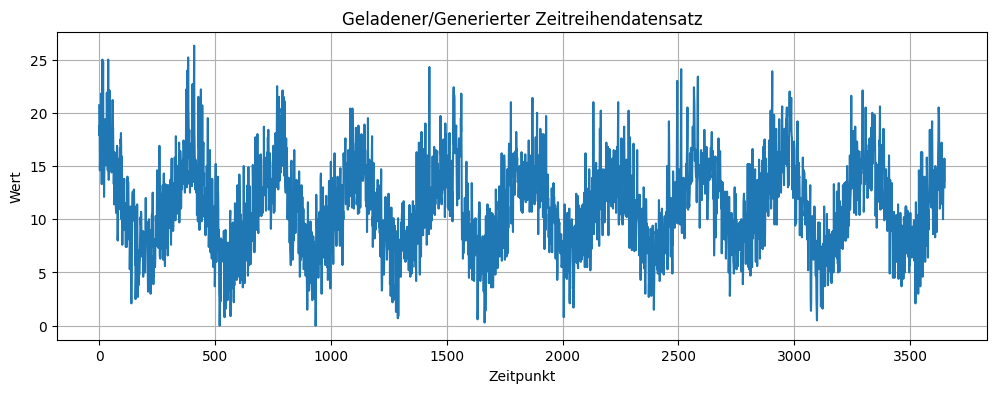

Datensatzgröße: 3650 Punkte


In [ ]:
# Pfad zum heruntergeladenen Datensatz
data_path = "../../../data/daily-minimum-temperatures-in-me.csv"

# Laden des Datensatzes
# header=0 falls die erste Zeile Spaltennamen enthält.
# parse_dates=[0] versucht, die erste Spalte als Datum zu parsen.
# index_col=0 setzt die Datumsspalte als Index.
df_real = pd.read_csv(data_path, header=0, index_col=0, parse_dates=True)


# Konvertieren der Werte zu Float32 für PyTorch
raw_data = df_real.values.astype(np.float32)
print(f"Realen Datensatz geladen. Größe: {len(raw_data)} Punkte.")
print("Erste 5 Werte:", raw_data[:5])


# Visualisierung der geladenen/generierten Daten
plt.figure(figsize=(12, 4))
plt.plot(raw_data)
plt.title("Geladener/Generierter Zeitreihendatensatz")
plt.xlabel("Zeitpunkt")
plt.ylabel("Wert")
plt.grid(True)
plt.show()

print(f"Datensatzgröße: {len(raw_data)} Punkte")


In [ ]:
# Skalierung der Daten
# Reshape da MinMaxScaler 2D-Array erwartet
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(
    raw_data.reshape(-1, 1)
)

print("Daten skaliert. Beispiel (erste 5):", scaled_data[:5].flatten())


Daten skaliert. Beispiel (erste 5): [0.7870723 0.6806084 0.7148289 0.5551331 0.6007605]


### Sequenzen erstellen (Sliding Window)

Für beide Ansätze (naiv und rekurrent) müssen wir die Zeitreihe in Sequenzen umwandeln. Jede Eingabesequenz besteht aus `window_size` vergangenen Zeitpunkten, und die Ausgabe ist der unmittelbar nächste Zeitpunkt.

In [ ]:
def create_sequences(data, window_size):
    """
    Erstellt Zeitreihen-Sequenzen für das Training. Die vorangegangen Werte der Anzahl window_size
    sind eine Sequenz mit dem darauffolgenden Wert als Zielvariable. Output der Funktion sind einmal
    ein  Array mit veschiedenen Arrays aus Sequenzen und das zweite Array sind die zugehörigen
    Zielvariablen.
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        # x_i ist das Eingabefenster (vergangene Werte)
        x_i = data[i : (i + window_size), 0]
        # y_i ist der vorherzusagende nächste Wert
        y_i = data[i + window_size, 0]
        X.append(x_i)
        y.append(y_i)
    return np.array(X), np.array(y)


window_size = 10  # Die Anzahl der vergangenen Zeitpunkte, die als Eingabe dienen

X_sequences, y_targets = create_sequences(scaled_data, window_size)

print(f"Anzahl der erstellten Sequenzen: {len(X_sequences)}")
print(
    f"Form der Eingabesequenzen (X): {X_sequences.shape}"
)  # (Anzahl Sequenzen, Window Size)
print(f"Form der Zielwerte (y): {y_targets.shape}")  # (Anzahl Sequenzen,)

# Daten in Trainings- und Testsets aufteilen (chronologisch)
# Es ist wichtig, Zeitreihen chronologisch aufzuteilen, um Datenlecks zu vermeiden.
train_size = int(len(X_sequences) * 0.8)
X_train_np, X_test_np = (
    X_sequences[0:train_size],
    X_sequences[train_size : len(X_sequences)],
)
y_train_np, y_test_np = y_targets[0:train_size], y_targets[train_size : len(y_targets)]

print(f"Trainingsdaten X Form: {X_train_np.shape}, y Form: {y_train_np.shape}")
print(f"Testdaten X Form: {X_test_np.shape}, y Form: {y_test_np.shape}")

# Konvertierung zu PyTorch Tensoren
X_train_tensor = torch.from_numpy(X_train_np).float()
y_train_tensor = (
    torch.from_numpy(y_train_np).float().view(-1, 1)
)  # y muss 2D sein für den Loss (Spalte)
X_test_tensor = torch.from_numpy(X_test_np).float()
y_test_tensor = (
    torch.from_numpy(y_test_np).float().view(-1, 1)
)  # y muss 2D sein für den Loss (Spalte)

print(
    f"Trainingsdaten X Tensor Form: {X_train_tensor.shape}, y Tensor Form: {y_train_tensor.shape}"
)


Anzahl der erstellten Sequenzen: 3640
Form der Eingabesequenzen (X): (3640, 10)
Form der Zielwerte (y): (3640,)
Trainingsdaten X Form: (2912, 10), y Form: (2912,)
Testdaten X Form: (728, 10), y Form: (728,)
Trainingsdaten X Tensor Form: torch.Size([2912, 10]), y Tensor Form: torch.Size([2912, 1])


### Naiver Ansatz: Feed-Forward Neuronales Netz (FFNN)

Beim 'naiven Ansatz' wird das Eingabefenster (z.B. die letzten 10 Zeitpunkte) einfach zu einem langen Vektor 'flachgewalzt' und als Input in ein traditionelles Feed-Forward Netz gegeben. Das Netz behandelt die aufeinanderfolgenden Zeitpunkte im Fenster als unabhängige Merkmale, ignoriert also explizit die sequenzielle Natur.

In [ ]:
class NaiveFFNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NaiveFFNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = (
            nn.ReLU()
        )  # Aktivierungsfunktion nach der ersten versteckten Schicht
        self.fc2 = nn.Linear(hidden_size, output_size)  # Output Schicht

    def forward(self, x):
        # Verknüpfen der Schichten
        out = self.relu(self.fc1(x))
        out = self.fc2(out)
        return out


# Modellparameter
# Die Größe des Eingabefensters ist der Input für das FFNN
ffnn_input_size = (
    window_size
)

# Anzahl der Neuronen in der versteckten Schicht
ffnn_hidden_size = 50

# Der nächste Werte nach der Sequenz
ffnn_output_size = 1

ffnn_model = NaiveFFNN(ffnn_input_size, ffnn_hidden_size, ffnn_output_size)

print("Naive FFNN Modellarchitektur:")
print(ffnn_model)


Naive FFNN Modellarchitektur:
NaiveFFNN(
  (fc1): Linear(in_features=10, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=1, bias=True)
)


In [ ]:
# Verlustfunktion
ffnn_criterion = (
    nn.MSELoss()
)
# Optimierer
ffnn_optimizer = optim.Adam(
    ffnn_model.parameters(), lr=0.001
)

# Anzahl Trainingsepochen
num_epochs = 100
# Speichern zur späteren Darstellung
ffnn_train_losses = []

print("Starte Training des naiven FFNN...")
for epoch in range(num_epochs):
    # Trainingsmodus
    ffnn_model.train()

    # Gradienten in jeder Iteration zurücksetzen
    ffnn_optimizer.zero_grad()

    # Generiere Vorhersagen
    outputs = ffnn_model(X_train_tensor)

    # Verlust berechnen
    loss = ffnn_criterion(outputs, y_train_tensor)

    # Gradienten berechnen
    loss.backward()

    # Gewichte aktualisieren
    ffnn_optimizer.step()

    # Verlust für Epoche speichern
    ffnn_train_losses.append(loss.item())  # Verlust für die aktuelle Epoche speichern

    # Ausgabe des Trainingsfortschritts alle 10 Epochen
    if (epoch + 1) % 10 == 0:
        print(f"FFNN Epoche [{epoch + 1}/{num_epochs}], Verlust: {loss.item():.6f}")

print("Training des naiven FFNN beendet.")


Starte Training des naiven FFNN...
FFNN Epoche [10/100], Verlust: 0.008788
FFNN Epoche [20/100], Verlust: 0.008722
FFNN Epoche [30/100], Verlust: 0.008704
FFNN Epoche [40/100], Verlust: 0.008701
FFNN Epoche [50/100], Verlust: 0.008695
FFNN Epoche [60/100], Verlust: 0.008689
FFNN Epoche [70/100], Verlust: 0.008683
FFNN Epoche [80/100], Verlust: 0.008678
FFNN Epoche [90/100], Verlust: 0.008671
FFNN Epoche [100/100], Verlust: 0.008665
Training des naiven FFNN beendet.


In [ ]:
# Setze Modell in Evaluierungsmodus (deaktiviert z.B. Dropout)
ffnn_model.eval()
# Deaktiviere Gradientenberechnung für die Inferenz, spart Speicher und Zeit
with (
    torch.no_grad()
):
    # Vorhersagen auf dem Testset
    ffnn_predictions = ffnn_model(X_test_tensor).numpy()

    # Berechne MSE und RMSE
    ffnn_mse = mean_squared_error(y_test_np, ffnn_predictions)
    ffnn_rmse = math.sqrt(ffnn_mse)
    print(f"Naive FFNN MSE auf Testset: {ffnn_mse:.6f}")
    print(f"Naive FFNN RMSE auf Testset: {ffnn_rmse:.6f}")


Naive FFNN MSE auf Testset: 0.007065
Naive FFNN RMSE auf Testset: 0.084051


### Zweite Variante: LSTM 

LSTM Modell berücksichtigt die zeitlche Vergangenheit und hat ein "Langzeitgedächtnis"

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        # Initialisieren der Eigenschaften des NN Moduls
        super(LSTMModel, self).__init__()

        # Setzen der Größe der Neuronen und der Schichten
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM-Layer
        # input_size: Dimension der Merkmale eines einzelnen Zeitpunktes (hier 1 für univariate Zeitreihe)
        # hidden_size: Dimension der versteckten und Zellzustände
        # num_layers: Anzahl der LSTM-Layer im Stack
        # batch_first=True: Input-Tensor hat die Form (batch_size, sequence_length, input_size)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Linearer Layer für die Ausgabe
        # Wandelt den Output des LSTM (letzter versteckter Zustand) in die gewünschte output_size um
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialisiere versteckte Zustände (h0) und Zellzustände (c0) für den LSTM-Layer
        # Diese Zustände werden am Anfang jeder Sequenz auf Null gesetzt.
        # Form: (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward-Pass durch den LSTM-Layer
        # out: Output-Features für jeden Zeit-Schritt der Sequenz (batch_size, sequence_length, hidden_size)
        # (hn, cn): Letzter versteckter Zustand und Zellzustand des gesamten Batches
        out, _ = self.lstm(x, (h0, c0))

        # Für die Vorhersage verwenden wir die Ausgabe des LSTM vom LETZTEN Zeit-Schritt der Sequenz.
        # out[:, -1, :] selektiert den letzten Zeit-Schritt (sequence_length-1) für alle Samples im Batch
        out = self.fc(out[:, -1, :])
        return out


# Modellparameter
lstm_input_size = 1  # Da unsere Zeitreihe univariat ist (ein Feature pro Zeitpunkt)
lstm_hidden_size = 50  # Anzahl der Neuronen im versteckten Zustand des LSTM
lstm_num_layers = 2  # Anzahl der übereinander gestapelten LSTM-Layer
lstm_output_size = 1  # Wir sagen den nächsten einzelnen Zeitpunkt voraus

# Erstelle das LSTM-Modell und verschiebe es auf die CPU (falls keine GPU verfügbar)
lstm_model = LSTMModel(
    lstm_input_size, lstm_hidden_size, lstm_num_layers, lstm_output_size
).to(torch.device("cpu"))

print("LSTM Modellarchitektur:")
print(lstm_model)


LSTM Modellarchitektur:
LSTMModel(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


In [9]:
# Reshape der Daten für LSTM-Input: (batch_size, sequence_length, input_size)
# .view(-1, window_size, lstm_input_size) fügt die 'input_size' Dimension hinzu.
X_train_lstm = X_train_tensor.view(
    X_train_tensor.size(0), window_size, lstm_input_size
).to(torch.device("cpu"))
X_test_lstm = X_test_tensor.view(
    X_test_tensor.size(0), window_size, lstm_input_size
).to(torch.device("cpu"))

print(f"Trainingsdaten X für LSTM Form: {X_train_lstm.shape}")
print(f"Testdaten X für LSTM Form: {X_test_lstm.shape}")


Trainingsdaten X für LSTM Form: torch.Size([2912, 10, 1])
Testdaten X für LSTM Form: torch.Size([728, 10, 1])


### Training des LSTM Models

In [ ]:
# Verlustfunktion
lstm_criterion = nn.MSELoss()
# Optimizer
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

# Liste zur Speicherung des Verlustverlaufs
lstm_train_losses = []

print("Starte Training des LSTM Modells...")
for epoch in range(num_epochs):
    # Setze Modell in Trainingsmodus
    lstm_model.train()

    # Gradienten zurücksetzen
    lstm_optimizer.zero_grad()

    # Forward pass
    outputs = lstm_model(X_train_lstm)

    # Verlust berechnen
    loss = lstm_criterion(outputs, y_train_tensor)

    # Gradienten berechnen
    loss.backward()

    # Gewichte aktualisieren
    lstm_optimizer.step()

    # Verlust speichern
    lstm_train_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"LSTM Epoche [{epoch + 1}/{num_epochs}], Verlust: {loss.item():.6f}")

print("Training des LSTM Modells beendet.")


Starte Training des LSTM Modells...
LSTM Epoche [10/100], Verlust: 0.059632
LSTM Epoche [20/100], Verlust: 0.033170
LSTM Epoche [30/100], Verlust: 0.023278
LSTM Epoche [40/100], Verlust: 0.022320
LSTM Epoche [50/100], Verlust: 0.021643
LSTM Epoche [60/100], Verlust: 0.020420
LSTM Epoche [70/100], Verlust: 0.019002
LSTM Epoche [80/100], Verlust: 0.016768
LSTM Epoche [90/100], Verlust: 0.013466
LSTM Epoche [100/100], Verlust: 0.012425
Training des LSTM Modells beendet.


### Evaluierung des LSTM Modells

In [ ]:
# Setze Modell in Evaluierungsmodus
lstm_model.eval()

# Deaktiviere Gradientenberechnung
with torch.no_grad():
    # Generiere Vorhersagen
    outputs = lstm_model(X_test_lstm)

    # Konvertiere PyTorch Tensor zu NumPy Array
    lstm_predictions = outputs.numpy()

    # Berechne MSE und RMSE
    lstm_mse = mean_squared_error(y_test_np, lstm_predictions)
    lstm_rmse = math.sqrt(lstm_mse)
    print(f"LSTM MSE auf Testset: {lstm_mse:.6f}")
    print(f"LSTM RMSE auf Testset: {lstm_rmse:.6f}")


LSTM MSE auf Testset: 0.011093
LSTM RMSE auf Testset: 0.105326


## Vergleich und Visualisierung

Wir vergleichen die Leistung beider Modelle (FFNN und LSTM) anhand des RMSE auf dem Testset. Anschließend visualisieren wir die Vorhersagen beider Modelle gegen die tatsächlichen Werte für einen kleinen Abschnitt der Zeitreihe, um die Unterschiede in der Vorhersagequalität visuell zu erkennen.


--- Modellvergleich ---
Naive FFNN RMSE: 0.107888
LSTM RMSE: 0.105326
Das LSTM-Modell hat eine bessere Leistung (niedrigeren RMSE) als das naive FFNN.


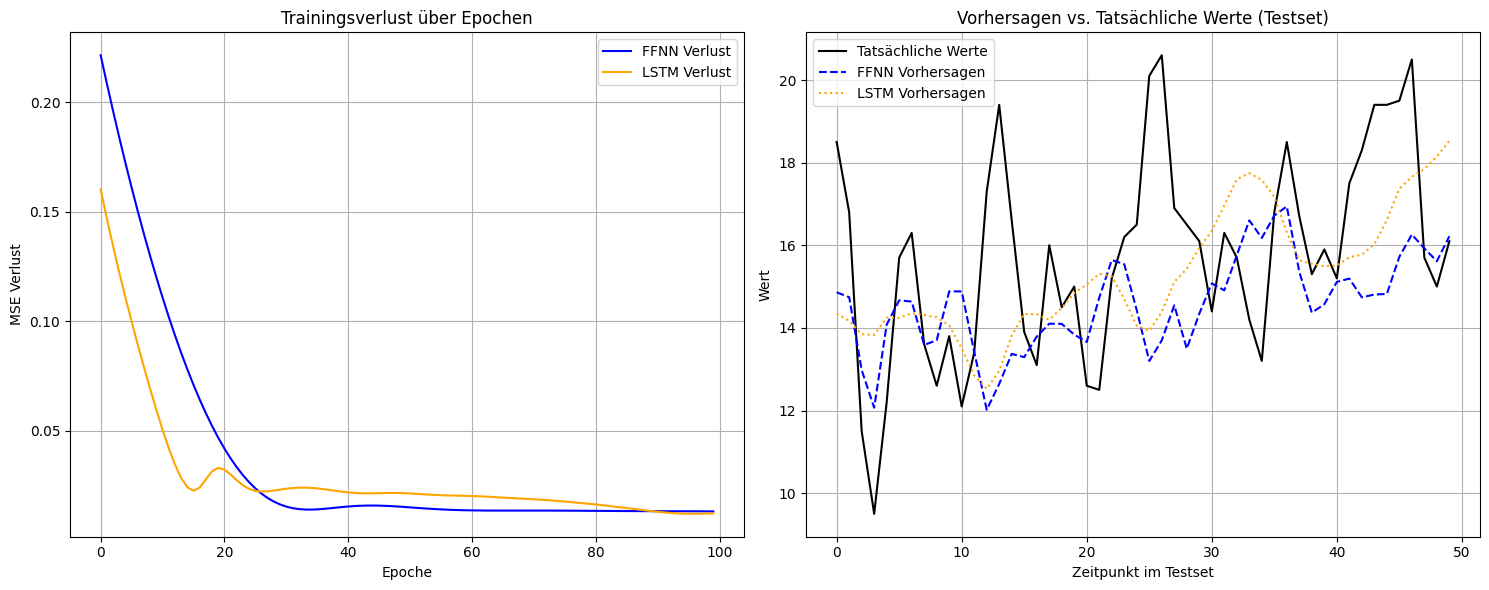

In [ ]:
print("\n--- Modellvergleich ---")
print(f"Naive FFNN RMSE: {ffnn_rmse:.6f}")
print(f"LSTM RMSE: {lstm_rmse:.6f}")

if lstm_rmse < ffnn_rmse:
    print(
        "Das LSTM-Modell hat eine bessere Leistung (niedrigeren RMSE) als das naive FFNN."
    )
else:
    print(
        "Das naive FFNN hat eine bessere oder gleiche Leistung (niedrigeren RMSE) wie das LSTM-Modell."
    )


# Visualisierungen der Vorhersagen
plt.figure(figsize=(15, 6))

# Plot 1: Konvergenz der Trainingsverluste beider Modelle
plt.subplot(1, 2, 1)  # 1 Zeile, 2 Spalten, erstes Plot
plt.plot(ffnn_train_losses, label="FFNN Verlust", color="blue")
plt.plot(lstm_train_losses, label="LSTM Verlust", color="orange")
plt.title("Trainingsverlust über Epochen")
plt.xlabel("Epoche")
plt.ylabel("MSE Verlust")
plt.legend()
plt.grid(True)

# Plot 2: Vorhersagen im Vergleich zu den tatsächlichen Werten (Testset)
plt.subplot(1, 2, 2)  # 1 Zeile, 2 Spalten, zweites Plot

# Inverse Skalierung der Daten für eine verständlichere Visualisierung
# Wir zeigen nur einen kleinen Abschnitt des Testsets zur besseren Lesbarkeit
plot_start_idx = 0
plot_end_idx = 50  # Visualisiere die ersten 50 Punkte des Testsets

y_test_original_scale = scaler.inverse_transform(y_test_np.reshape(-1, 1)).flatten()
ffnn_predictions_original_scale = scaler.inverse_transform(ffnn_predictions).flatten()
lstm_predictions_original_scale = scaler.inverse_transform(lstm_predictions).flatten()

time_indices = np.arange(plot_start_idx, plot_end_idx)

plt.plot(
    time_indices,
    y_test_original_scale[plot_start_idx:plot_end_idx],
    label="Tatsächliche Werte",
    color="black",
)
plt.plot(
    time_indices,
    ffnn_predictions_original_scale[plot_start_idx:plot_end_idx],
    label="FFNN Vorhersagen",
    color="blue",
    linestyle="--",
)
plt.plot(
    time_indices,
    lstm_predictions_original_scale[plot_start_idx:plot_end_idx],
    label="LSTM Vorhersagen",
    color="orange",
    linestyle=":",
)

plt.title("Vorhersagen vs. Tatsächliche Werte (Testset)")
plt.xlabel("Zeitpunkt im Testset")
plt.ylabel("Wert")
plt.legend()
plt.grid(True)

plt.tight_layout()  # Passt das Layout an, um Überlappungen zu vermeiden
plt.show()
